In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from xgboost import XGBClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer

In [2]:
df_org = pd.read_csv('Data/Bank Customer Churn Prediction.csv')

In [3]:
cat_cols = ['country', 'gender']
o_h_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat = o_h_encoder.fit_transform(df_org[cat_cols])
features_names = o_h_encoder.get_feature_names_out(cat_cols)
df_X_cat = pd.DataFrame(X_cat, columns=features_names, index=df_org.index)
df_org_new = pd.concat([df_org, df_X_cat], axis=1)

In [4]:
df_org_processing = df_org_new.drop(['country', 'gender'], axis=1)
df_org_processing

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_France,country_Germany,country_Spain,gender_Female,gender_Male
0,15634602,619,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0,1.0,0.0
1,15647311,608,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0,1.0,0.0
2,15619304,502,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0,1.0,0.0
3,15701354,699,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0,1.0,0.0
4,15737888,850,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,39,5,0.00,2,1,0,96270.64,0,1.0,0.0,0.0,0.0,1.0
9996,15569892,516,35,10,57369.61,1,1,1,101699.77,0,1.0,0.0,0.0,0.0,1.0
9997,15584532,709,36,7,0.00,1,0,1,42085.58,1,1.0,0.0,0.0,1.0,0.0
9998,15682355,772,42,3,75075.31,2,1,0,92888.52,1,0.0,1.0,0.0,0.0,1.0


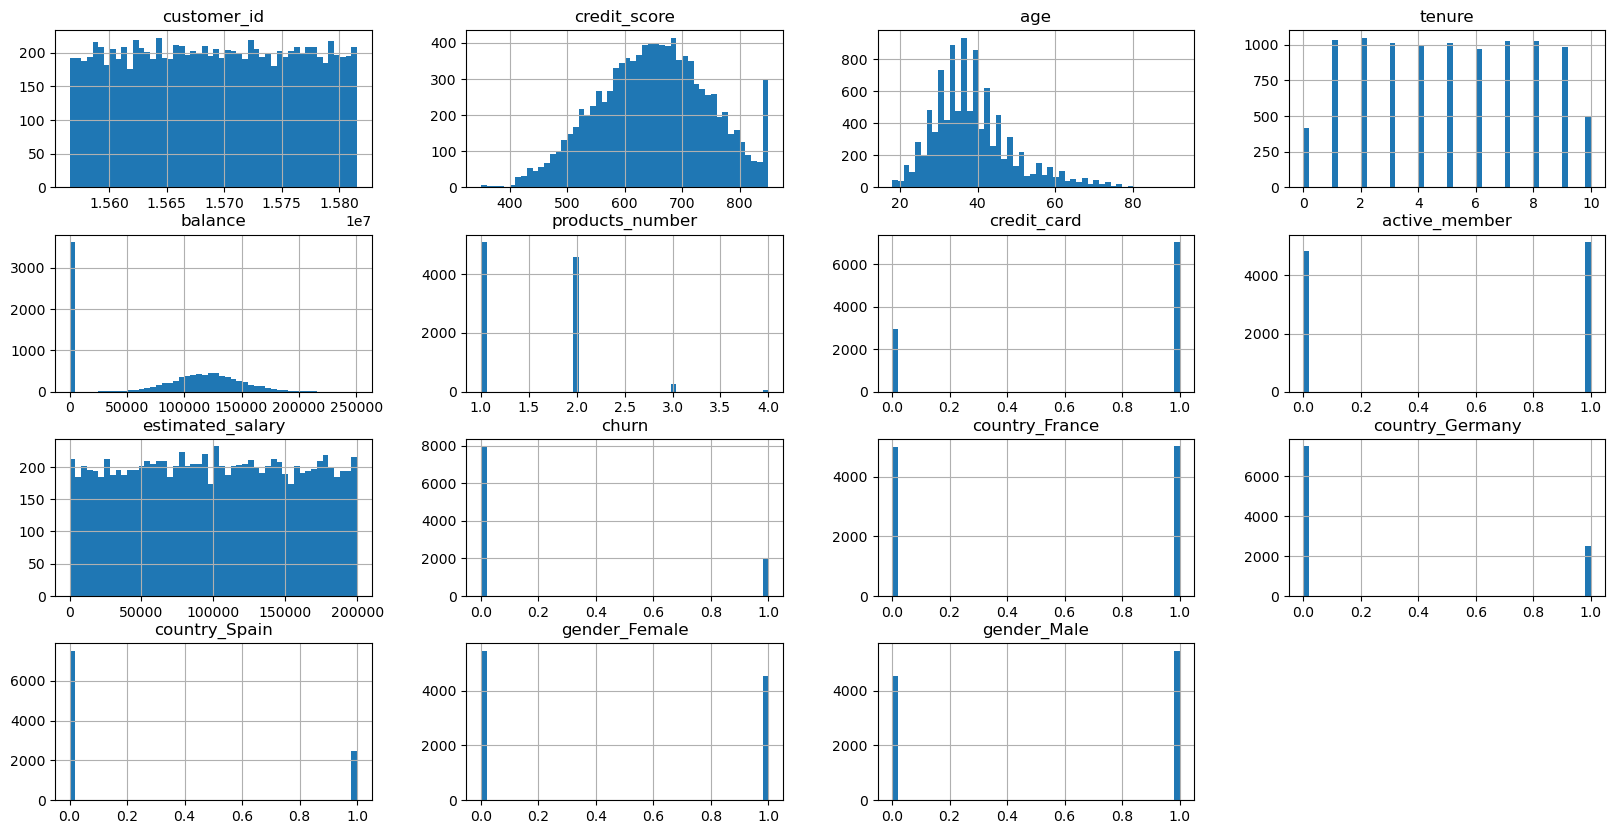

In [5]:
df_org_processing.hist(bins=50, figsize=(20, 10))
plt.show()

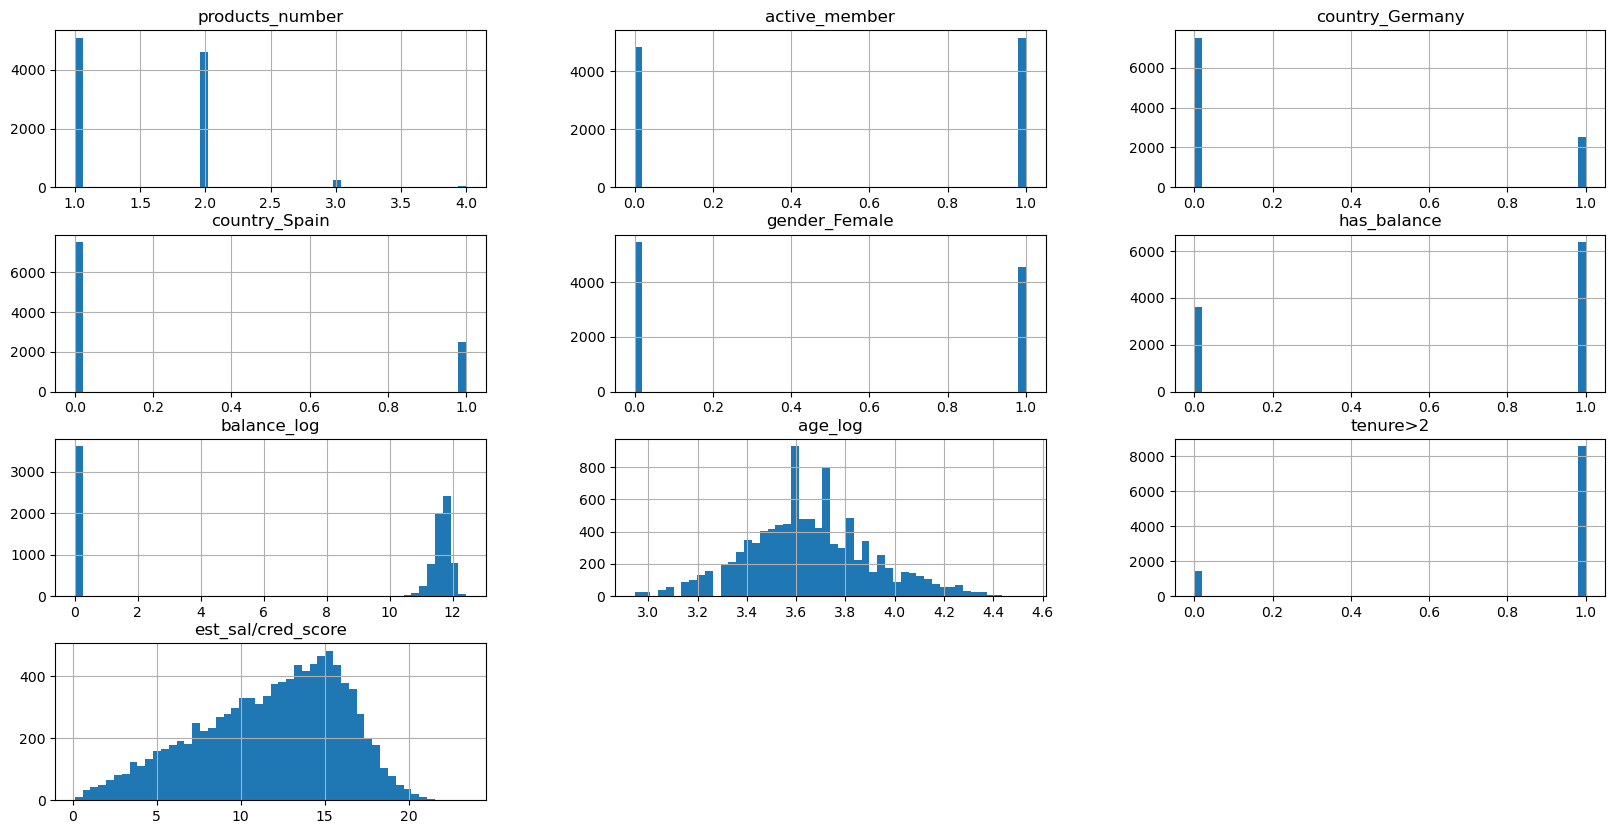

In [6]:
X = df_org_processing.drop(['churn', 'customer_id'], axis=1)
y = df_org_processing['churn']


def feature_in(df):
    df = df.copy()
    df['has_balance'] = (df['balance'] > 0).astype(int)
    df['balance_log'] = np.log1p(df['balance'])
    df['age_log'] = np.log1p(df['age'])
    df['tenure>2'] = (df['tenure'] >= 2).astype(int)
    df['est_sal/cred_score'] = np.sqrt(df['estimated_salary'] / df['credit_score'])
    col_to_drop = ['age', 'balance', 'country_France', 'gender_Male', 'credit_score', 'tenure', 'estimated_salary',
                   'credit_card']
    df = df.drop(col_to_drop, axis=1)
    return df


X = feature_in(X)
X.hist(bins=50, figsize=(20, 10))
plt.show()






In [7]:
df_org_SVC = pd.read_csv('Data/Bank Customer Churn Prediction.csv')
df_org_SVC = df_org_SVC.drop('customer_id', axis=1)
y = df_org_SVC['churn']
X = df_org_SVC.drop('churn', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


def feature_in_SVC(df):
    df = df.copy()
    df['has_balance'] = (df['balance'] > 0).astype(int)
    df['balance_log'] = np.log1p(df['balance'])
    df['age_log'] = np.log1p(df['age'])
    df['tenure>2'] = (df['tenure'] >= 2).astype(int)
    df['est_sal/cred_score'] = np.sqrt(df['estimated_salary'] / df['credit_score'])
    col_to_drop = ['age', 'balance', 'credit_score', 'tenure', 'estimated_salary', 'credit_card']
    df = df.drop(col_to_drop, axis=1)
    return df


X_train = feature_in_SVC(X_train)
X_test = feature_in_SVC(X_test)
num_X_svc = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_X_svc = X_train.select_dtypes(include=['object', 'string']).columns

num_piline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
cat_piline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
prepecesing_SVC = ColumnTransformer([
    ('num_piline', num_piline, num_X_svc),
    ('cat_piline', cat_piline, cat_X_svc)
])

model_SVC = Pipeline([('preprocessor_SVC', prepecesing_SVC),
                      ('model_SVC_v1', SVC(probability=True))])

for test in ["precision", "recall", "roc_auc"]:
    punkty_model_SVC = cross_val_score(estimator=model_SVC, X=X_train, y=y_train, cv=10, scoring=test)
    print(test, ": ", punkty_model_SVC.mean().round(2))


precision :  0.83
recall :  0.38
roc_auc :  0.83


start:
precision :  0.81
recall :  0.38
roc_auc :  0.83
po fe:
precision :  0.83
recall :  0.38
roc_auc :  0.83

In [8]:
model_SVC

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor_SVC', ...), ('model_SVC_v1', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_piline', ...), ('cat_piline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the 

In [9]:
model_SVC.fit(X_train, y_train)
for sco in ["recall", "roc_auc"]:
    f_imp = permutation_importance(estimator=model_SVC, X=X_test, y=y_test, n_jobs=-1, random_state=42, scoring=sco,
                                   n_repeats=10)
    df_f_imp = pd.DataFrame({
        'feature': X_test.columns,
        'importance': f_imp.importances_mean
    }).sort_values(by='importance', ascending=False)
    print(sco, ": ", df_f_imp)



recall :                feature  importance
2     products_number    0.168796
6             age_log    0.142015
3       active_member    0.065111
0             country    0.038084
1              gender    0.006388
8  est_sal/cred_score    0.004177
7            tenure>2   -0.001229
4         has_balance   -0.004914
5         balance_log   -0.009091
roc_auc :                feature  importance
6             age_log    0.147098
2     products_number    0.108080
3       active_member    0.031161
4         has_balance    0.028604
0             country    0.028469
5         balance_log    0.020214
1              gender    0.004365
7            tenure>2    0.000899
8  est_sal/cred_score   -0.007281
